<a href="https://colab.research.google.com/github/simsim-px/Praktikum-Fisika/blob/main/MP4_RADIOAKTIVITAS1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving datamp4.xlsx to datamp4.xlsx
R0      = 33.98 counts/s
Lambda  = 0.000004 s⁻¹
T½      = 166528.19 s


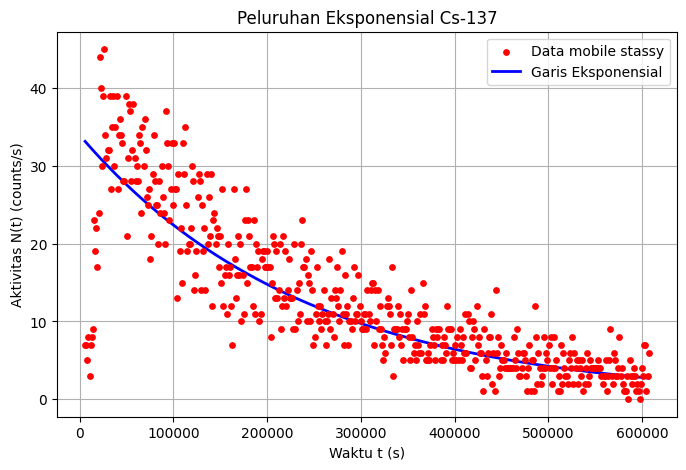

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

try:
    df = pd.read_excel(filename, header=None, skiprows=5)
    data = df.values
except Exception as e:
    raise RuntimeError(f"Gagal membaca file: {e}")

if len(data) < 2:
    raise ValueError("Data kurang dari 2 baris setelah header.")

t = data[:, 0].astype(float)   #waktu (s)
N = data[:, 1].astype(float)   #aktivitas (counts/s)

valid   = N > 0
t_valid = t[valid]
N_valid = N[valid]

if len(t_valid) < 2:
    raise ValueError(
        f"Hanya ada {len(t_valid)} titik dengan R > 0. "
        "Minimal diperlukan 2 titik untuk fitting."
    )

lnR = np.log(N_valid)
p   = np.polyfit(t_valid, lnR, 1)

lam    = -p[0]
R0     = np.exp(p[1])
t_half = np.log(2) / lam

print(f"R0      = {R0:.2f} counts/s")
print(f"Lambda  = {lam:.6f} s⁻¹")
print(f"T½      = {t_half:.2f} s")

t_fit = np.linspace(t_valid.min(), t_valid.max(), 500)
N_fit = R0 * np.exp(-lam * t_fit)

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(t, N, s=15, color='red', label='Data mobile stassy', zorder=3)
ax.plot(t_fit, N_fit, color='blue', linewidth=2, label='Garis Eksponensial')

ax.set_xlabel('Waktu t (s)')
ax.set_ylabel('Aktivitas N(t) (counts/s)')
ax.set_title('Peluruhan Eksponensial Cs-137')
ax.legend()
ax.grid(True)

Saving datamp4.xlsx to datamp4 (1).xlsx
Hasil fitting linear:
  Slope (a)     = -0.000047 counts/s²
  Intercept (b) = 27.26 counts/s


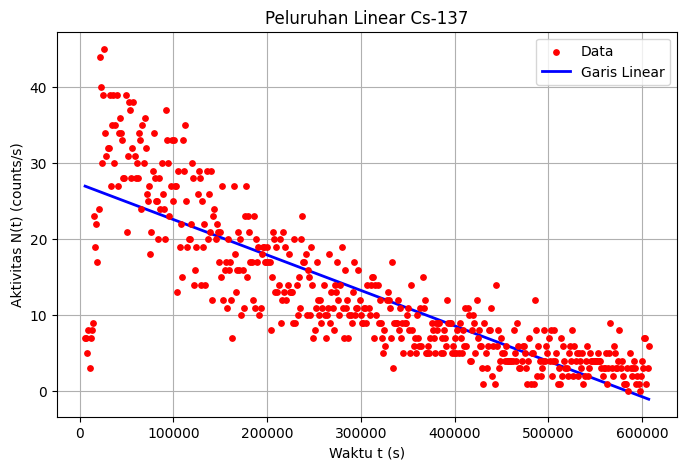

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]

try:
    df = pd.read_excel(filename, header=None, skiprows=5)
    data = df.values
except Exception as e:
    raise RuntimeError(f"Gagal membaca file: {e}")

if len(data) < 2:
    raise ValueError("Data kurang dari 2 baris setelah header.")

t = data[:, 0].astype(float)
N = data[:, 1].astype(float)

valid   = N > 0
t_valid = t[valid]
N_valid = N[valid]

if len(t_valid) < 2:
    raise ValueError(
        f"Hanya ada {len(t_valid)} titik dengan R > 0. "
        "Minimal diperlukan 2 titik untuk fitting."
    )

p = np.polyfit(t_valid, N_valid, 1)
a = p[0]
b = p[1]

print("Hasil fitting linear:")
print(f"  Slope (a)     = {a:.6f} counts/s²")
print(f"  Intercept (b) = {b:.2f} counts/s")

t_fit = np.linspace(t_valid.min(), t_valid.max(), 500)
N_fit = a * t_fit + b

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(t, N, s=15, color='red', label='Data', zorder=3)
ax.plot(t_fit, N_fit, color='blue', linewidth=2, label='Garis Linear')

ax.set_xlabel('Waktu t (s)')
ax.set_ylabel('Aktivitas N(t) (counts/s)')
ax.set_title('Peluruhan Linear Cs-137')
ax.legend(loc='best')
ax.grid(True)

Tanpa Halangan: y = 3.7764 * exp(-0.0693 * x)
Kertas HVS: y = 2.5811 * exp(-0.0752 * x)
Aluminium Foil: y = 1.0000 * exp(0.0000 * x)


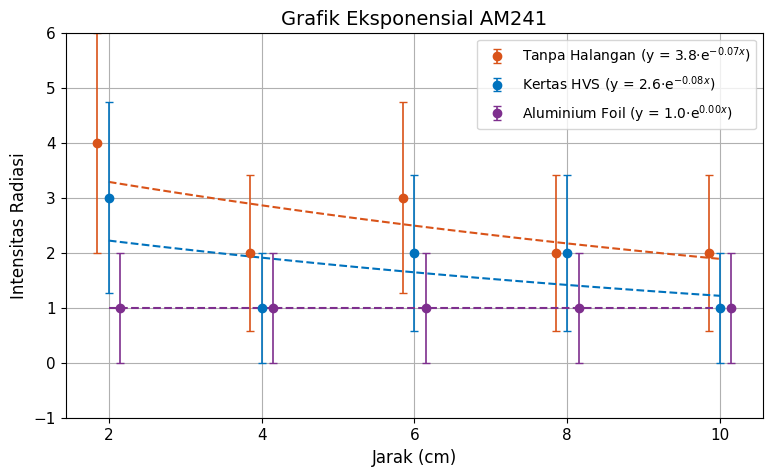

In [16]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([2, 4, 6, 8, 10])

y_tanpa  = np.array([4, 2, 3, 2, 2], dtype=float)
y_kertas = np.array([3, 1, 2, 2, 1], dtype=float)
y_alum   = np.array([1, 1, 1, 1, 1], dtype=float)

datasets = [y_tanpa, y_kertas, y_alum]
labels   = ['Tanpa Halangan', 'Kertas HVS', 'Aluminium Foil']
colors   = ['#D95319', '#0072BD', '#7E2F8E']
offsets  = [-0.15, 0, 0.15]

fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
ax.grid(True)

x_smooth = np.linspace(2, 10, 100)

for i, (yi, label, color, offset) in enumerate(zip(datasets, labels, colors, offsets)):

    y_for_fit = yi.copy()
    y_for_fit[y_for_fit == 0] = 0.05

    p = np.polyfit(x, np.log(y_for_fit), 1)
    b = p[0]
    a = np.exp(p[1])

    print(f"{label}: y = {a:.4f} * exp({b:.4f} * x)")

    y_smooth = a * np.exp(b * x_smooth)
    ax.plot(x_smooth, y_smooth, '--', color=color, linewidth=1.5)

    ei = np.sqrt(yi)
    ei[yi == 0] = 0.5

    ax.errorbar(
        x + offset, yi, yerr=ei,
        fmt='o', color=color, markerfacecolor=color,
        linewidth=1.2, capsize=3,
        label=f'{label} (y = {a:.1f}·e$^{{{b:.2f}x}}$)'
    )

ax.set_xlabel('Jarak (cm)', fontsize=12)
ax.set_ylabel('Intensitas Radiasi', fontsize=12)
ax.set_title('Grafik Eksponensial AM241', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(-1, y_tanpa.max() + 2)
ax.tick_params(labelsize=11)

Tanpa Halangan: Y = -0.0693x + 1.3288
Kertas HVS: Y = -0.0752x + 0.9482
Aluminium Foil: Y = 0.0000x + 0.0000


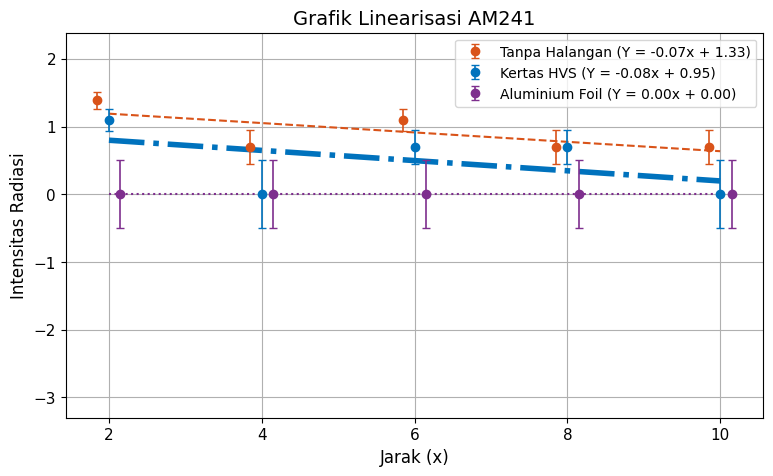

In [15]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([2, 4, 6, 8, 10], dtype=float)

y_tanpa  = np.array([4, 2, 3, 2, 2], dtype=float)
y_kertas = np.array([3, 1, 2, 2, 1], dtype=float)
y_alum   = np.array([1, 1, 1, 1, 1], dtype=float)

datasets    = [y_tanpa, y_kertas, y_alum]
labels      = ['Tanpa Halangan', 'Kertas HVS', 'Aluminium Foil']
colors      = ['#D95319', '#0072BD', '#7E2F8E']
line_styles = ['--', '-.', ':']
line_widths = [1.5, 4.0, 1.5]
offsets     = [-0.15, 0, 0.15]

fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
ax.grid(True)

x_fit = np.linspace(x.min(), x.max(), 100)

for yi, label, color, ls, lw, offset in zip(
        datasets, labels, colors, line_styles, line_widths, offsets):

    y_linear = yi.copy()
    y_linear[y_linear == 0] = 0.1
    Yi = np.log(y_linear)

    p = np.polyfit(x, Yi, 1)
    m, c = p[0], p[1]

    print(f"{label}: Y = {m:.4f}x + {c:.4f}")

    Y_fit = m * x_fit + c
    ax.plot(x_fit, Y_fit, ls, color=color, linewidth=lw)

    ei = 0.5 / y_linear

    ax.errorbar(
        x + offset, Yi, yerr=ei,
        fmt='o', color=color, markerfacecolor=color,
        linewidth=1.2, capsize=3,
        label=f'{label} (Y = {m:.2f}x + {c:.2f})'
    )

ax.set_xlabel('Jarak (x)', fontsize=12)
ax.set_ylabel('Intensitas Radiasi', fontsize=12)
ax.set_title('Grafik Linearisasi AM241', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(np.log(0.1) - 1, np.log(4) + 1)
ax.tick_params(labelsize=11)

Tanpa Halangan: y = 17.58 * exp(-0.18 * x)
Sylinc: y = 12.64 * exp(-0.19 * x)
Aluminium Foil: y = 12.27 * exp(-0.24 * x)


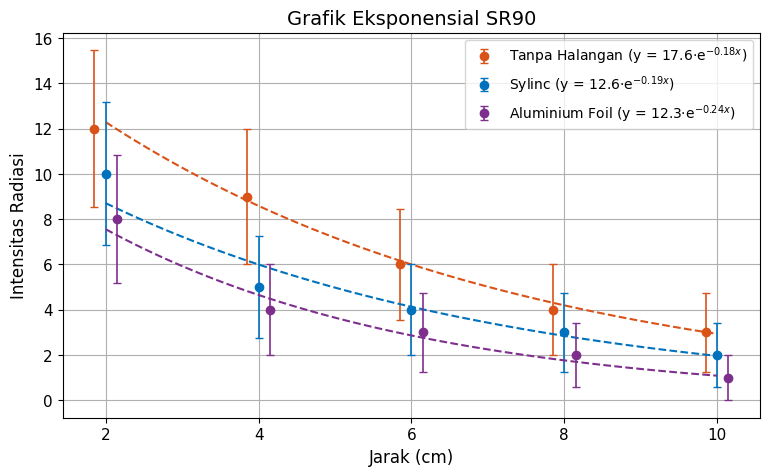

In [14]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([2, 4, 6, 8, 10], dtype=float)

y_tanpa  = np.array([12, 9, 6, 4, 3], dtype=float)
y_kertas = np.array([10, 5, 4, 3, 2], dtype=float)
y_alum   = np.array([8, 4, 3, 2, 1], dtype=float)

datasets = [y_tanpa,  y_kertas, y_alum]
labels   = ['Tanpa Halangan', 'Sylinc', 'Aluminium Foil']
colors   = ['#D95319', '#0072BD', '#7E2F8E']
offsets  = [-0.15, 0, 0.15]

fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
ax.grid(True)

x_fit = np.linspace(x.min(), x.max(), 100)

for yi, label, color, offset in zip(datasets, labels, colors, offsets):

    ei = np.sqrt(yi)

    p = np.polyfit(x, np.log(yi), 1)
    b = p[0]
    a = np.exp(p[1])

    print(f"{label}: y = {a:.2f} * exp({b:.2f} * x)")

    ax.errorbar(
        x + offset, yi, yerr=ei,
        fmt='o', color=color, markerfacecolor=color,
        linewidth=1.2, capsize=3,
        label=f'{label} (y = {a:.1f}·e$^{{{b:.2f}x}}$)'
    )

    ax.plot(x_fit, a * np.exp(b * x_fit), '--', color=color, linewidth=1.5)

ax.set_xlabel('Jarak (cm)', fontsize=12)
ax.set_ylabel('Intensitas Radiasi', fontsize=12)
ax.set_title('Grafik Eksponensial SR90', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.tick_params(labelsize=11)

Tanpa Halangan: Y = -0.1792*x + 2.8668
Sylinc: Y = -0.1865*x + 2.5369
Aluminium Foil: Y = -0.2426*x + 2.5071


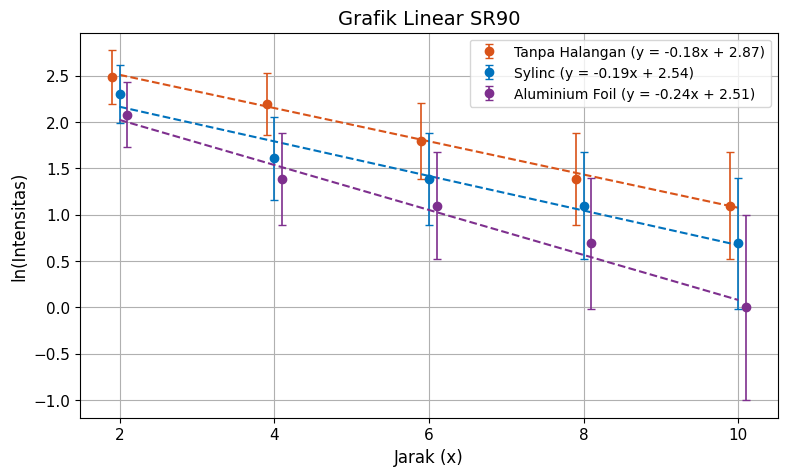

In [13]:
import numpy as np
import matplotlib.pyplot as plt

x = np.array([2, 4, 6, 8, 10], dtype=float)

y_tanpa  = np.array([12, 9, 6, 4, 3], dtype=float)
y_sylinc = np.array([10, 5, 4, 3, 2], dtype=float)
y_alum   = np.array([8, 4, 3, 2, 1], dtype=float)

ln_y_tanpa  = np.log(y_tanpa)
ln_y_kertas = np.log(y_sylinc)
ln_y_alum   = np.log(y_alum)

err_tanpa  = 1 / np.sqrt(y_tanpa)
err_kertas = 1 / np.sqrt(y_sylinc)
err_alum   = 1 / np.sqrt(y_alum)

datasets = [ln_y_tanpa,  ln_y_kertas,  ln_y_alum]
errsets  = [err_tanpa,   err_kertas,   err_alum]
labels   = ['Tanpa Halangan', 'Sylinc', 'Aluminium Foil']
colors   = ['#D95319', '#0072BD', '#7E2F8E']
offsets  = [-0.1, 0, 0.1]

fig, ax = plt.subplots(figsize=(9, 5), facecolor='white')
ax.grid(True)

x_fit = np.linspace(x.min(), x.max(), 100)

for Yi, Ei, label, color, offset in zip(
        datasets, errsets, labels, colors, offsets):

    p = np.polyfit(x, Yi, 1)
    m, c = p[0], p[1]

    print(f"{label}: Y = {m:.4f}*x + {c:.4f}")

    ax.errorbar(
        x + offset, Yi, yerr=Ei,
        fmt='o', color=color, markerfacecolor=color,
        linewidth=1.2, capsize=3,
        label=f'{label} (y = {m:.2f}x + {c:.2f})'
    )

    ax.plot(x_fit, m * x_fit + c, '--', color=color, linewidth=1.5)

ax.set_xlabel('Jarak (x)', fontsize=12)
ax.set_ylabel('ln(Intensitas)', fontsize=12)
ax.set_title('Grafik Linear SR90', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.tick_params(labelsize=11)

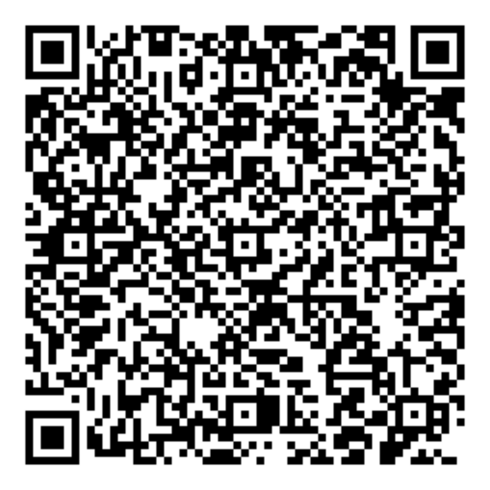

In [21]:
!pip install qrcode[pil] -q

import qrcode
import matplotlib.pyplot as plt

data = "https://colab.research.google.com/github/simsim-px/Praktikum-Fisika/blob/main/MP4_RADIOAKTIVITAS1.ipynb"

qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_H,
    box_size=3,
    border=2,
)
qr.add_data(data)
qr.make(fit=True)

img = qr.make_image(fill_color="black", back_color="white")

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()